# 🛫 Session 2 — Predictive Aircraft Maintenance
## ALICE Club · Applied AI Workshop · UTM Faculty of AI · July 2026

**✅ Correction version** — all code is complete.

---

## 1 · Where we left off — Session 1 in sixty seconds

Last week you built a clean, leak-free dataset from the raw NASA C-MAPSS sensor files. Let's remember exactly what that means before we build anything new on top of it.

| What we did in Session 1 | Why it matters today |
|---|---|
| Loaded `train_FD001.txt` (100 engines, 21 sensors, 3 operating settings) | This is still our raw material |
| Built the target `RUL = max_cycles − current_cycle`, clipped at 125 | We reuse this exact target, unchanged |
| Identified sensor_11 (Ps30) as a strong degradation signal, and ~10 sensors as near-constant | Today we finally **act** on this — drop the useless ones, enrich the useful ones |
| Split the data **by engine** (80 train / 10 val / 10 test), never by row | This split is the foundation of everything we do today — we reuse it exactly |

**Today's mission:** turn this clean dataset into an actual working prediction system — one that doesn't just output a number, but one you could defend in front of a maintenance engineer.

## 2 · Why Session 2 exists

A clean dataset is not a working system. Today we walk the full path from "clean sensors" to "explainable prediction that supports a maintenance decision":

```
Feature Engineering  →  Baseline  →  ML Models  →  Metrics  →  Explainable AI
```

Each step exists because of a limitation of the previous one. We'll build that story together, cell by cell, instead of jumping straight to the fanciest model.

> ⚠️ **Ground rule for the whole session, worth repeating from Session 1:** anything that is *learned* from data — a scaler, a baseline statistic, a choice of features — is learned **only on the training engines**. Never on validation, never on test. We'll come back to this rule at every step where it matters.

## 3 · Setup

We reload the raw files and rebuild the Session 1 pipeline in a compressed form — same code, same seed, same result. Why redo it instead of loading last week's saved CSV? Because we need to keep the `unit_number` column a little longer today, to build per-engine rolling features — and last week's saved file dropped it on purpose (it's an ID, not a feature). Rebuilding from raw data is one extra minute, and it doubles as a great two-minute recap.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time, warnings, os
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
os.makedirs('outputs', exist_ok=True)

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 12})

In [2]:
# 📌 Same mount as Session 1 — adjust the path if your Drive folder differs
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive/DATA_DIR/'


Mounted at /content/drive


In [3]:
# Same column names as Session 1
COL_NAMES = (
    ['unit_number', 'time_in_cycles',
     'op_setting_1', 'op_setting_2', 'op_setting_3']
    + [f'sensor_{i:02d}' for i in range(1, 22)]
)

def load_cmapss(filepath):
    df = pd.read_csv(filepath, sep=r'\s+', header=None, engine='python')
    df.dropna(axis=1, how='all', inplace=True)
    df.columns = COL_NAMES
    return df

### Rebuilding the Session 1 result — RUL and the engine-level split

The next two cells are exactly the logic from Session 1: build the RUL target, clip it at 125, then split **by engine**, never by row. If this feels like déjà vu, that's the point — you already know why every line here exists.

In [4]:
train_df = load_cmapss(DATA_DIR + 'train_FD001.txt')

# RUL construction — identical to Session 1
engine_lives = train_df.groupby('unit_number')['time_in_cycles'].max().reset_index()
engine_lives.rename(columns={'time_in_cycles': 'max_cycles'}, inplace=True)
train_df = train_df.merge(engine_lives, on='unit_number')
train_df['RUL_raw'] = train_df['max_cycles'] - train_df['time_in_cycles']
train_df['RUL'] = train_df['RUL_raw'].clip(upper=125)

print(f'Loaded {train_df.shape[0]:,} rows across {train_df["unit_number"].nunique()} engines')

Loaded 20,631 rows across 100 engines


In [5]:
# Engine-level split — identical seed and proportions as Session 1 (80 / 10 / 10)
np.random.seed(RANDOM_STATE)
all_engines = train_df['unit_number'].unique()
np.random.shuffle(all_engines)

train_engines = all_engines[:80]
val_engines   = all_engines[80:90]
test_engines  = all_engines[90:]

df_train = train_df[train_df['unit_number'].isin(train_engines)].copy()
df_val   = train_df[train_df['unit_number'].isin(val_engines)].copy()
df_test  = train_df[train_df['unit_number'].isin(test_engines)].copy()

assert set(train_engines) & set(val_engines)  == set(), 'Leakage detected!'
assert set(train_engines) & set(test_engines) == set(), 'Leakage detected!'

print(f'Train: {len(train_engines)} engines — {len(df_train):,} rows')
print(f'Val:   {len(val_engines)} engines — {len(df_val):,} rows')
print(f'Test:  {len(test_engines)} engines — {len(df_test):,} rows')
print('✓ No leakage — every engine belongs to exactly one set.')

Train: 80 engines — 16,340 rows
Val:   10 engines — 2,082 rows
Test:  10 engines — 2,209 rows
✓ No leakage — every engine belongs to exactly one set.


---
## 4 · Feature Engineering — turning raw sensors into usable signal

**Big picture.** A model doesn't understand jet engines. It only sees numbers, and it looks for statistical patterns between those numbers and the RUL. Our job is to present those numbers in a way that makes the degradation signal as visible as possible — and to remove anything that's just noise.

Two concrete actions today:
1. **Actually drop** the near-constant sensors that Session 1 only *identified* (they're still sitting in the raw data).
2. **Add rolling features** (rolling mean, rolling std) so the model sees a *trend*, not just an isolated noisy value — without ever using the raw cycle number, which stays forbidden for the same leakage reason as Session 1.

In [6]:
# Which sensors carry real signal? Decide using TRAIN ONLY — never val/test.
sensor_cols = [c for c in df_train.columns if c.startswith('sensor_')]

sensor_range = df_train[sensor_cols].max() - df_train[sensor_cols].min()
non_const = sensor_range[sensor_range > 1e-9].index.tolist()

mins, maxs = df_train[non_const].min(), df_train[non_const].max()
norm = (df_train[non_const] - mins) / (maxs - mins)
var_norm = norm.var().sort_values()

NORM_THRESH = 0.02
keep_sensors = var_norm[var_norm >= NORM_THRESH].index.tolist()
drop_sensors = var_norm[var_norm < NORM_THRESH].index.tolist()

print(f'Keeping {len(keep_sensors)} informative sensors')
print(f'Dropping {len(drop_sensors)} near-constant sensors: {drop_sensors}')

Keeping 7 informative sensors
Dropping 8 near-constant sensors: ['sensor_09', 'sensor_14', 'sensor_13', 'sensor_08', 'sensor_17', 'sensor_03', 'sensor_06', 'sensor_20']


### From a single noisy value to a trend

Remember the golden rule: `time_in_cycles` is never a model input, on its own it would let the model "memorise" how long engines usually live rather than learn true degradation. Instead, for each informative sensor, we compute a **rolling mean** and a **rolling standard deviation** over the last few cycles — computed **per engine**, so we never blend the end of one engine's life with the start of another's.

In [7]:
ROLL_WINDOW = 8  # cycles — a compromise: short enough to react, long enough to smooth noise

def add_rolling_features(df, sensors, window=ROLL_WINDOW):
    df = df.sort_values(['unit_number', 'time_in_cycles']).copy()
    for s in sensors:
        grouped = df.groupby('unit_number')[s]
        df[f'{s}_rmean'] = grouped.transform(lambda x: x.rolling(window, min_periods=1).mean())
        df[f'{s}_rstd']  = grouped.transform(lambda x: x.rolling(window, min_periods=1).std().fillna(0))
    return df

df_train_fe = add_rolling_features(df_train, keep_sensors)
df_val_fe   = add_rolling_features(df_val,   keep_sensors)
df_test_fe  = add_rolling_features(df_test,  keep_sensors)

print(f'Train shape after feature engineering: {df_train_fe.shape}')
assert df_train_fe.isnull().sum().sum() == 0, 'Unexpected NaNs after rolling features!'
print('✓ No missing values.')

Train shape after feature engineering: (16340, 43)
✓ No missing values.


### Seeing it: raw value vs. rolling mean

Let's look at one engine, one sensor, to confirm the rolling mean does what we expect: smooth the noise, reveal the trend.

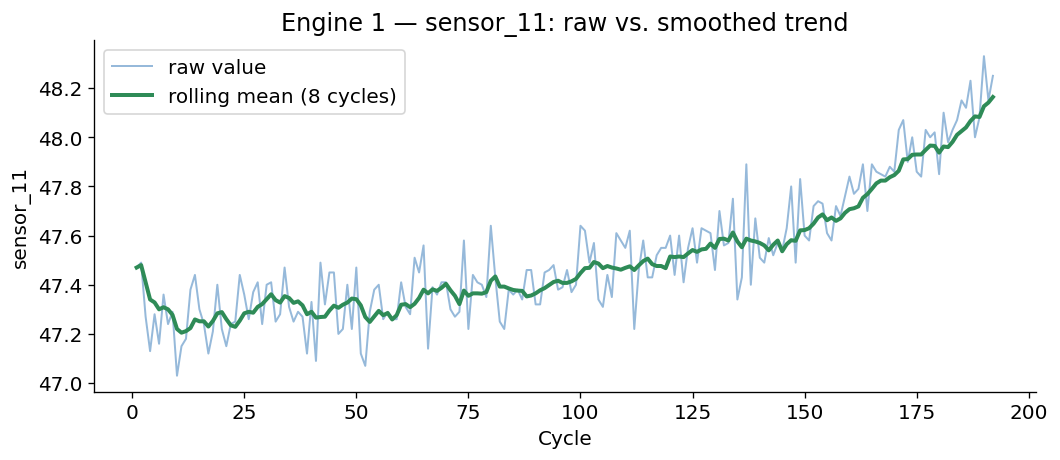

In [8]:
example_engine = df_train_fe['unit_number'].unique()[0]
sub = df_train_fe[df_train_fe['unit_number'] == example_engine]
# Prefer sensor_11 (Ps30) if it survived feature selection — it's the sensor we
# already know the physical story for from Session 1. Fall back otherwise.
sensor_to_show = 'sensor_11' if 'sensor_11' in keep_sensors else keep_sensors[0]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(sub['time_in_cycles'], sub[sensor_to_show], color='#2E75B6', alpha=0.5, lw=1.2, label='raw value')
ax.plot(sub['time_in_cycles'], sub[f'{sensor_to_show}_rmean'], color='#2E8B57', lw=2.4, label=f'rolling mean ({ROLL_WINDOW} cycles)')
ax.set_xlabel('Cycle'); ax.set_ylabel(sensor_to_show)
ax.set_title(f'Engine {example_engine} — {sensor_to_show}: raw vs. smoothed trend')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/rolling_feature_example.png', bbox_inches='tight')
plt.show()

**What to take away before moving on:** the raw blue line is noisy and hard to read cycle by cycle; the green line reveals the trend the model actually needs. This is exactly what feature engineering is for — not inventing information out of nowhere, but making existing information easier for the model to use.

We're not touching the target: `RUL` stays exactly as built in Session 1, clipped at 125. Feature engineering only concerns the **inputs**.

---
## 5 · The Baseline — a deliberately dumb point of reference

 Before trusting any sophisticated model, we need to know: how good is "good"? If a model gets a 20-cycle average error, is that impressive? Impossible to say without a point of comparison. The baseline answers that question: predict the **training mean RUL** for every single row, ignoring every sensor completely. Any real model must clearly beat this.

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(y_true, y_pred, train_time, name):
    """Compute MAE, RMSE, R2 and store training time — same scorecard for every model."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f'{name:<20} MAE={mae:6.2f}   RMSE={rmse:6.2f}   R2={r2:6.3f}   time={train_time:.3f}s')
    return {'model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'train_time_s': train_time}

results = []  # every model's scorecard will be appended here

# Baseline: always predict the TRAIN mean RUL (never computed on val/test — same anti-leakage rule)
baseline_value = df_train_fe['RUL'].mean()
baseline_pred_val = np.full(len(df_val_fe), baseline_value)

results.append(evaluate(df_val_fe['RUL'], baseline_pred_val, 0.0, 'Baseline (mean)'))

Baseline (mean)      MAE= 37.04   RMSE= 41.65   R2=-0.000   time=0.000s


**What to take away:** this baseline number is our line in the sand. Every model we train from now on will be judged first by a simple question — does it clearly beat this? If it doesn't, something is wrong before we even discuss which model is "best".

---
## 6 · The most dangerous trap: data leakage

You already met this idea in Session 1 through the engine-level split. Today it comes back in a sneakier form: **scaling**.

> ⚠️ **The rule that governs this entire section:** anything that is *learned* from data — a scaler's mean and standard deviation, the list of features we keep — must be learned **only on `df_train_fe`**. Never on validation, never on test. If you fit anything on val or test, your evaluation numbers will look great and mean nothing.

Let's first lock in our final list of model inputs, then scale them correctly.

In [10]:
op_cols = ['op_setting_1', 'op_setting_2', 'op_setting_3']
rolling_cols = [f'{s}_rmean' for s in keep_sensors] + [f'{s}_rstd' for s in keep_sensors]
feature_cols = op_cols + keep_sensors + rolling_cols

print(f'Final feature list: {len(feature_cols)} columns')
print(feature_cols)

X_train, y_train = df_train_fe[feature_cols], df_train_fe['RUL']
X_val,   y_val   = df_val_fe[feature_cols],   df_val_fe['RUL']
X_test,  y_test  = df_test_fe[feature_cols],  df_test_fe['RUL']

Final feature list: 24 columns
['op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_07', 'sensor_15', 'sensor_21', 'sensor_02', 'sensor_12', 'sensor_04', 'sensor_11', 'sensor_07_rmean', 'sensor_15_rmean', 'sensor_21_rmean', 'sensor_02_rmean', 'sensor_12_rmean', 'sensor_04_rmean', 'sensor_11_rmean', 'sensor_07_rstd', 'sensor_15_rstd', 'sensor_21_rstd', 'sensor_02_rstd', 'sensor_12_rstd', 'sensor_04_rstd', 'sensor_11_rstd']


### Scaling — fit on train, transform everywhere else

Why scale at all? Some models — the linear one we're about to train — combine each sensor's value with a coefficient; a sensor that naturally ranges in the thousands could dominate the calculation over one that ranges around fifty, simply because of its scale, not because it's more informative. Tree-based models don't care about scale, but scaling them does no harm, so we scale once and reuse the same tables for every model.

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_val_scaled   = pd.DataFrame(scaler.transform(X_val),       columns=feature_cols, index=X_val.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=feature_cols, index=X_test.index)

# 📌 fit_transform on train, transform (no refit) on val/test — this line is the one
# students most often get wrong by copy-pasting fit_transform everywhere.
print('Train mean after scaling (should be ~0):', round(X_train_scaled.mean().abs().max(), 6))

Train mean after scaling (should be ~0): 0.0


**What to take away before moving on:** three separate decisions were all made looking only at the 80 training engines — which sensors to keep, how to build rolling features, and how to scale. Validation and test engines never influenced any of these choices. That is exactly what makes the scores we're about to compute trustworthy.

---
## 7 · Four models, one story

We'll train four models, and — this matters more than the numbers — each one exists to fix a specific limitation of the one before it. A straight line, then a model that can bend but overfits, then a model that fixes the overfitting by averaging many trees, then a model that fixes the same problem a completely different way, by correcting errors in sequence. Watch how the story builds.

### Model 1 — Linear Regression: the best straight line

**Intuition first.** Linear Regression looks for the best straight line (or, with many sensors, a flat surface in many dimensions) through the cloud of points. It assumes each sensor contributes proportionally and independently to the RUL. Simple, transparent, but rigid: it can never bend to follow a degradation curve that accelerates sharply near failure.

In [12]:
from sklearn.linear_model import LinearRegression

t0 = time.time()
lin_model = LinearRegression()
lin_model.fit(X_train_scaled, y_train)
lin_time = time.time() - t0

lin_pred_val = lin_model.predict(X_val_scaled)
results.append(evaluate(y_val, lin_pred_val, lin_time, 'Linear Regression'))

Linear Regression    MAE= 18.73   RMSE= 22.79   R2= 0.701   time=0.039s


### Model 2 — Decision Tree: bending the line, at a cost

**Intuition first.** A Decision Tree asks a sequence of yes/no questions about the sensors ("is sensor_11's rolling mean above 47.5?") and keeps splitting engines into smaller, more homogeneous groups. It predicts the average RUL of whichever group a new engine falls into. This finally lets the model bend — but an unrestricted tree can ask so many precise questions that it ends up memorising individual training engines instead of learning a general rule. We limit its depth to keep it honest.

In [13]:
from sklearn.tree import DecisionTreeRegressor

t0 = time.time()
tree_model = DecisionTreeRegressor(max_depth=6, random_state=RANDOM_STATE)
tree_model.fit(X_train_scaled, y_train)
tree_time = time.time() - t0

tree_pred_val = tree_model.predict(X_val_scaled)
results.append(evaluate(y_val, tree_pred_val, tree_time, 'Decision Tree'))

Decision Tree        MAE= 16.48   RMSE= 21.86   R2= 0.725   time=0.224s


### Model 3 — Random Forest: three hundred mechanics voting

**Intuition first.** A single tree is unstable — small changes in the data can produce a very different tree. A Random Forest trains hundreds of trees, each on a random resample of engines and a random subset of sensors at every split, then **averages** their predictions. One tree can be wrong about a specific case; hundreds of independent trees rarely agree on the same mistake, so the average is far more stable and generalises much better.

In [14]:
from sklearn.ensemble import RandomForestRegressor

t0 = time.time()
rf_model = RandomForestRegressor(n_estimators=300, max_depth=10,
                                  random_state=RANDOM_STATE, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
rf_time = time.time() - t0

rf_pred_val = rf_model.predict(X_val_scaled)
results.append(evaluate(y_val, rf_pred_val, rf_time, 'Random Forest'))

Random Forest        MAE= 16.08   RMSE= 21.07   R2= 0.744   time=49.300s


### Model 4 — XGBoost: an assembly line that corrects its own mistakes

**Intuition first.** Random Forest's trees work in parallel and independently. XGBoost's trees work in a **chain**: the first tree makes a rough guess, the second tree is trained to predict exactly what the first one got wrong (its residual error), the third corrects what's still left, and so on. Same underlying idea as Gradient Boosting, with extra regularisation and speed. Two completely different philosophies for solving the same instability problem — parallel averaging versus sequential correction.

In [15]:
from xgboost import XGBRegressor

t0 = time.time()
xgb_model = XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                          random_state=RANDOM_STATE, n_jobs=-1,
                          objective='reg:squarederror')
xgb_model.fit(X_train_scaled, y_train)
xgb_time = time.time() - t0

xgb_pred_val = xgb_model.predict(X_val_scaled)
results.append(evaluate(y_val, xgb_pred_val, xgb_time, 'XGBoost'))

XGBoost              MAE= 16.03   RMSE= 21.12   R2= 0.743   time=0.770s


**What to take away before moving on:** all four models just did the exact same job — predict RUL from the same scaled sensors — but arrived at their predictions through four different philosophies. That's precisely the difference we now want to measure and visualise, not just describe in words.

---
## 8 · Reading the scoreboard properly

We've been printing MAE, RMSE and R2 after every model without stopping to unpack them. Now that we have five real numbers to look at side by side (baseline + 4 models), it's the right moment to understand exactly what each one is telling us.

- **MAE** (Mean Absolute Error): on average, how many cycles off is the model? Same unit as RUL.
- **RMSE** (Root Mean Squared Error): same idea, but it squares errors before averaging, so a handful of very large mistakes hurt this score much more than many small ones — RMSE ≥ MAE always, and the gap between them tells you how "spiky" the errors are.
- **R²**: what fraction of the variation in true RUL does the model explain, compared to always predicting the mean? 1 is perfect, 0 means "no better than the baseline", and negative means "worse than just guessing the mean" — a red flag worth investigating.

In [16]:
results_df = pd.DataFrame(results).sort_values('MAE').reset_index(drop=True)
results_df

,model,MAE,RMSE,R2,train_time_s
0,XGBoost,16.033960,21.118039,0.742801,0.769687
1,Random Forest,16.081058,21.072829,0.743901,49.299700
2,Decision Tree,16.475326,21.855948,0.724513,0.223992
3,Linear Regression,18.730000,22.787591,0.700526,0.039078
4,Baseline (mean),37.039408,41.647206,-0.000309,0.000000


### One picture is worth the whole table

A bar chart makes the comparison immediate — and it's the figure you'll want on screen while you discuss which model "wins", and on what basis.

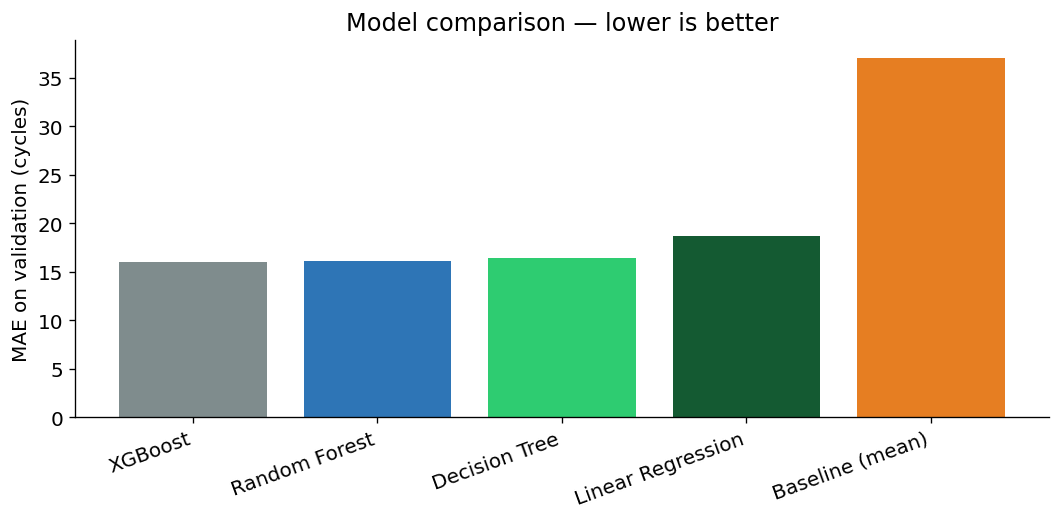

In [17]:
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ['#7F8C8D', '#2E75B6', '#2ECC71', '#145A32', '#E67E22']
ax.bar(results_df['model'], results_df['MAE'], color=colors[:len(results_df)])
ax.set_ylabel('MAE on validation (cycles)')
ax.set_title('Model comparison — lower is better')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('outputs/model_comparison_mae.png', bbox_inches='tight')
plt.show()

### Where does the best model still get it wrong?

A single MAE number can hide a lot. The residual plot shows the error for every engine in validation: a healthy model scatters randomly around zero with no visible pattern.

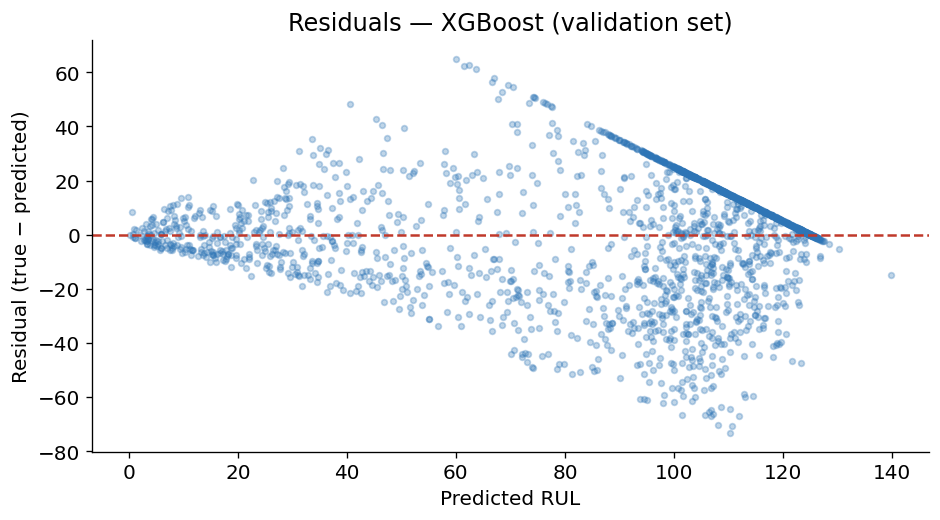

In [18]:
# Exclude the baseline here — we want the best REAL model, not the point of reference
real_models = results_df[results_df['model'] != 'Baseline (mean)']
best_name = real_models.iloc[0]['model']
best_preds = {'Linear Regression': lin_pred_val, 'Decision Tree': tree_pred_val,
              'Random Forest': rf_pred_val, 'XGBoost': xgb_pred_val}[best_name]

residuals = y_val.values - best_preds

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(best_preds, residuals, alpha=0.3, s=12, color='#2E75B6')
ax.axhline(0, color='#C0392B', lw=1.5, ls='--')
ax.set_xlabel('Predicted RUL'); ax.set_ylabel('Residual (true − predicted)')
ax.set_title(f'Residuals — {best_name} (validation set)')
plt.tight_layout()
plt.savefig('outputs/residuals_best_model.png', bbox_inches='tight')
plt.show()

**What to take away before moving on:** whichever model sits on top of the table above by MAE is our current "winner" — but winning is only half the conversation. Look at the residual plot together with the class: is the spread roughly even, or does the model systematically struggle on low-RUL engines, exactly the engines a maintenance team cares about most? That question matters as much as the headline number.